#### Model with Gating at position G (at attention calculation step) :  As in Paper where stated best effective

In [ ]:
### Aplied gated atention at position G elementwise

In [ ]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

In [ ]:
import random
import numpy as np
import torch

SEED = 12

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

set_seed(SEED)
torch.use_deterministic_algorithms(True)

In [ ]:
# Rope

def compute_rope_params(seq_len, head_dim, device=None):
    # x: (seq_len, dim)

    assert head_dim % 2 == 0, "head_dim must be even for RoPE"

    theta = 1.0 / (10000 ** (torch.arange(0, head_dim, 2).float() / head_dim))

    pos = torch.arange(seq_len).float()

    angles = pos[:, None] * theta[None, :]


    angles = angles[None, None, :, :]

    return torch.cos(angles), torch.sin(angles)



# similar to sebastian
def apply_rope(x, cos, sin, offset=0):

    batch_size, num_heads, seq_len, head_dim = x.shape   # (batch_size, num_heads, seq_len, head_dim)

    assert head_dim % 2 == 0, "Head dimension must be even"

    cos_sel = cos[...,offset : offset + seq_len, :].to(x.device, x.dtype)  #(1,1,seq_len,head_dim//2)
    sin_sel = sin[..., offset : offset + seq_len, :].to(x.device, x.dtype)

    x_even = x[..., 0::2]  # (b,n_heads,seq_len,head_dim//2)
    x_odd  = x[..., 1::2]


    x_rot = torch.empty_like(x)

    x_rot[..., 0::2] = x_even * cos_sel - x_odd * sin_sel
    x_rot[..., 1::2] = x_even * sin_sel + x_odd * cos_sel

    return x_rot.to(dtype=x.dtype)

In [ ]:
import torch
from torch import nn


class causal_multi_head_transformer(nn.Module):
    def __init__(self, din, dout, context_length, dropout, ff_dim, num_heads, qk_norm, pre_norm, post_norm, vocab_size, qkv_bias=False):
        super().__init__()
        self.num_heads = num_heads

        assert dout % num_heads == 0, f"d_out must be divisible by num_heads {dout // num_heads}"

        self.head_dim = dout // num_heads

        self.context_length = context_length



        self.wq = nn.Linear(din, dout, bias = qkv_bias)
        self.wk = nn.Linear(din, dout, bias = qkv_bias)
        self.wv = nn.Linear(din, dout, bias = qkv_bias)
        self.dropout = nn.Dropout(dropout)

        self.out_proj = nn.Linear(dout, dout)  # Linear layer to combine head outputs


        # Feedforward
        self.ff = nn.Sequential(nn.Linear(din, ff_dim),
                                            nn.ReLU(), nn.Linear(ff_dim, din),)
        self.norm1 = nn.RMSNorm(din)
        self.norm2 = nn.RMSNorm(din)

        self.apply_rope = apply_rope

        self.gate = nn.Linear(din, self.num_heads * self.head_dim)

        nn.init.zeros_(self.gate.weight)
        nn.init.constant_(self.gate.bias, 2.0)  # sigmoid(2)  0.88
        # or for even closer to identity
        # nn.init.constant_(self.gate.bias, 4.0)  # sigmoid(4)  0.98

        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length, dtype=torch.bool), diagonal=1)
        )

        self.qk_norm  = qk_norm
        self.pre_norm = pre_norm
        self.post_norm = post_norm


        if self.qk_norm:
            self.q_norm = nn.RMSNorm(self.head_dim)
            self.k_norm = nn.RMSNorm(self.head_dim)

        if self.pre_norm and self.post_norm:
          self.post_attn_norm = nn.RMSNorm(dout)
          self.post_ff_norm = nn.RMSNorm(dout)
          self.pre_ff_norm = nn.RMSNorm(dout)

    def forward(self, x, cos, sin, start_pos):

        b, num_tokens, d_in = x.shape

        assert num_tokens <= self.context_length

        #Pre-LN
        if self.pre_norm:
          x_norm = self.norm1(x)

        else:
          x_norm =x

        q = self.wq(x_norm)
        k = self.wk(x_norm)
        v = self.wv(x_norm)

        k = k.view(b, num_tokens, self.num_heads, self.head_dim)
        v = v.view(b, num_tokens, self.num_heads, self.head_dim)
        q = q.view(b, num_tokens, self.num_heads, self.head_dim)


        k = k.transpose(1,2)  # reshape to (b, num_heads, num_tokens, head_dim)
        v = v.transpose(1,2)
        q = q.transpose(1,2)

        #QK normalization (optional)
        if self.qk_norm:
            q = self.q_norm(q)
            k = self.k_norm(k)

        q_enc = self.apply_rope(q, cos, sin, start_pos)
        k_enc = self.apply_rope(k, cos, sin, start_pos)

        attn_scores = q_enc @ k_enc.transpose(2,3)    # (b, num_heads, num_tokens, head_dim) @ (b, num_heads, head_dim, num_tokens)

        attn_scores = attn_scores / (self.head_dim ** 0.5)

        mask = self.mask[:num_tokens, :num_tokens]
        masked = attn_scores.masked_fill(mask.bool(), float('-inf'))

        attn_weights = torch.softmax(masked, dim=-1)                             # shape: (b, num_heads, num_tokens, num_tokens)
        attn_weights = self.dropout(attn_weights)
        z = (attn_weights @ v)

        #gate applied elemnetwise

        gate_val = self.gate(x_norm)

        gate_val = gate_val.view(b, num_tokens, self.num_heads, self.head_dim)
        gate_val = gate_val.transpose(1,2)


        z = z * torch.sigmoid(gate_val)

       # Reshape and project
        z = z.transpose(1,2).contiguous().view(b, num_tokens, -1)  # Reshape to (b, num_tokens, num_heads * head_dim)
        attn_out = self.out_proj(z)

        # after attention output
        if self.pre_norm and self.post_norm:
          attn_out = self.post_attn_norm(attn_out)
          x = x + attn_out

          ff_out = self.ff(self.pre_ff_norm(x))
          ff_out = self.post_ff_norm(ff_out)
          x = x + ff_out

        elif self.pre_norm:                       #  Pre-LN
          x= x + attn_out
          x = x + self.ff(self.norm2(x))

        elif self.post_norm:                    #  Post-LN
          x = self.norm1(x + attn_out)
          x = self.norm2(x + self.ff(x))

        sink_val = attn_weights[:, :, :, 0].mean(dim=-1)

        return x, gate_val, sink_val

In [ ]:
class Gated_Transformer_LM(nn.Module):
  def __init__(self, din, dout, context_length, dropout, ff_dim, num_heads, vocab_size, qk_norm, pre_norm, post_norm, n_transformer):
    super().__init__()


    assert din == dout

    self.embedding = nn.Embedding(vocab_size, din)


    self.dstack = nn.ModuleList([causal_multi_head_transformer(din, dout, context_length, dropout, ff_dim, num_heads, qk_norm, pre_norm, post_norm, vocab_size)
    for _ in range(n_transformer)])

    cos, sin = compute_rope_params(context_length, din//num_heads)

    # register so they move with the model and are saved in state_dict
    self.register_buffer("rope_cos", cos)
    self.register_buffer("rope_sin", sin)

    self.cos, self.sin = cos, sin

    self.final_norm = nn.RMSNorm(din)
    self.out_head = nn.Linear(
        din, vocab_size, bias=False
    )


  def forward(self, inp, start_pos: int = 0):
      gate_vals = []
      attn_sink_val = []

      x = self.embedding(inp)

      for layer in self.dstack:
        x, gate_val, sink_info = layer(x, self.cos, self.sin, start_pos)

        gate_vals.append(gate_val)
        attn_sink_val.append(sink_info)

      x = self.final_norm(x)
      logits = self.out_head(x)


      return logits, gate_vals, attn_sink_val # Only return logits, as gate_val is not computed

### Model without Gating

In [ ]:
import torch
from torch import nn

class causal_multi_head_transformer_no_gate(nn.Module):
    def __init__(self, din, dout, context_length, dropout, ff_dim, num_heads, qk_norm, pre_norm, post_norm, vocab_size, qkv_bias=False):
        super().__init__()
        self.num_heads = num_heads

        assert dout % num_heads == 0, f"d_out must be divisible by num_heads {dout // num_heads}"

        self.head_dim = dout // num_heads

        self.context_length = context_length

        self.wq = nn.Linear(din, dout, bias = qkv_bias)
        self.wk = nn.Linear(din, dout, bias = qkv_bias)
        self.wv = nn.Linear(din, dout, bias = qkv_bias)
        self.dropout = nn.Dropout(dropout)

        self.out_proj = nn.Linear(dout, dout)  # Linear layer to combine head outputs


        # Feedforward
        self.ff = nn.Sequential( nn.Linear(din, ff_dim),
                                            nn.ReLU(), nn.Linear(ff_dim, din), )
        self.norm1 = nn.RMSNorm(din)
        self.norm2 = nn.RMSNorm(din)

        self.apply_rope = apply_rope

        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length, dtype=torch.bool), diagonal=1)
        )

        self.qk_norm  = qk_norm
        self.pre_norm = pre_norm
        self.post_norm = post_norm


        if self.qk_norm:
          self.q_norm = nn.RMSNorm(self.head_dim)
          self.k_norm = nn.RMSNorm(self.head_dim)

        if self.pre_norm and self.post_norm:
          self.post_attn_norm = nn.RMSNorm(dout)
          self.post_ff_norm = nn.RMSNorm(dout)
          self.pre_ff_norm = nn.RMSNorm(dout)


    def forward(self, x, cos, sin, start_pos):

        b, num_tokens, d_in = x.shape

        assert num_tokens <= self.context_length

        #Pre-LN

        if self.pre_norm:
          x_norm = self.norm1(x)

        else:
          x_norm =x

        q = self.wq(x_norm)
        k = self.wk(x_norm)
        v = self.wv(x_norm)

        k = k.view(b, num_tokens, self.num_heads, self.head_dim)
        v = v.view(b, num_tokens, self.num_heads, self.head_dim)
        q = q.view(b, num_tokens, self.num_heads, self.head_dim)


        k = k.transpose(1,2)  # reshape to (b, num_heads, num_tokens, head_dim)
        v = v.transpose(1,2)
        q = q.transpose(1,2)

        #QK normalization (optional)
        # Qk normalization L2 norm return unit vectors q/|q| = 1, k/|k| = 1 which scales the values in q.k = cos (theta) and range of values [-1, 1]
        # and no magnitude scale is taken in consideration in SDPA q.k/root(head_dim) which limits the range of values to [-1/root(head_dim), 1/root(head_dim)].
        # can add learnable paramereter Y which can change the scale [-1/root(head_dim) * y, 1/root(head_dim)] * y]
        # if self.qk_norm:
        #     q = q / (q.norm(dim=-1, keepdim=True) + 1e-6)
        #     k = k / (k.norm(dim=-1, keepdim=True) + 1e-6)

        # QK norm with RMSNorm (common with LLM models)

        if self.qk_norm:
            q = self.q_norm(q)
            k = self.k_norm(k)



        q_enc = self.apply_rope(q, cos, sin, start_pos)
        k_enc = self.apply_rope(k, cos, sin, start_pos)

        attn_scores = q_enc @ k_enc.transpose(2,3)
        attn_scores = attn_scores / (self.head_dim ** 0.5)

        mask = self.mask[:num_tokens, :num_tokens]
        masked = attn_scores.masked_fill(mask.bool(), float('-inf'))

        attn_weights = torch.softmax(masked, dim=-1)
        attn_weights = self.dropout(attn_weights)
        z = (attn_weights @ v)

        # Gating mechanism removed

       # Reshape and project
        z = z.transpose(1,2).contiguous().view(b, num_tokens, -1)  # Reshape to (b, num_tokens, num_heads, head_dim)
        attn_out = self.out_proj(z)

        # after attention output
        if self.pre_norm and self.post_norm:
          attn_out = self.post_attn_norm(attn_out)
          x = x + attn_out

          ff_out = self.ff(self.pre_ff_norm(x))
          ff_out = self.post_ff_norm(ff_out)
          x = x + ff_out


        elif self.pre_norm:                       #  Pre-LN
          x= x + attn_out
          x = x + self.ff(self.norm2(x))

        elif self.post_norm:                    #  Post-LN
          x = self.norm1(x + attn_out)
          x = self.norm2(x + self.ff(x))


        sink_val = attn_weights[:, :, :, 0].mean(dim=-1)

        return x,  sink_val # Only return x, as gate_val is not computed

In [ ]:
class Transformer_No_Gate(nn.Module):
  def __init__(self, din, dout, context_length, dropout, ff_dim, num_heads, vocab_size, qk_norm, pre_norm, post_norm, n_transformer):
    super().__init__()

    self.embedding = nn.Embedding(vocab_size, din)


    self.dstack = nn.ModuleList([causal_multi_head_transformer_no_gate(din, dout, context_length, dropout, ff_dim, num_heads, qk_norm, pre_norm, post_norm, vocab_size)
    for _ in range(n_transformer)])

    cos, sin = compute_rope_params(context_length, din//num_heads)

    # register so they move with the model and are saved in state_dict
    self.register_buffer("rope_cos", cos)
    self.register_buffer("rope_sin", sin)

    self.cos, self.sin = cos, sin

    self.final_norm = nn.RMSNorm(din)
    self.out_head = nn.Linear(
        din, vocab_size, bias=False
    )


  def forward(self, inp, start_pos: int = 0):
      attn_sink_val = []
      x = self.embedding(inp)

      for layer in self.dstack:
        x, sink_info = layer(x, self.cos, self.sin, start_pos)
        attn_sink_val.append(sink_info)

      x = self.final_norm(x)
      logits = self.out_head(x)


      return logits, attn_sink_val # Only return logits, as gate_val is not computed


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from transformers import AutoTokenizer


# -----------------------------
# Load Dataset
# -----------------------------
dataset = load_dataset("wikitext", "wikitext-2-raw-v1")

texts = dataset["train"]["text"]
texts = [t for t in texts if len(t.strip()) > 0]


# -----------------------------
# Tokenizer (FAST)
# -----------------------------
tokenizer = AutoTokenizer.from_pretrained("gpt2", use_fast=True)
tokenizer.pad_token = tokenizer.eos_token


# -----------------------------
# FAST Tokenization (BATCHED)
# -----------------------------
encodings = tokenizer(
    texts,
    padding=False,
    truncation=False
)

# Flatten tokens + add EOS between docs
all_tokens = [
    token
    for ids in encodings["input_ids"]
    for token in (ids + [tokenizer.eos_token_id])
]

tokens = torch.tensor(all_tokens, dtype=torch.long)


# -----------------------------
# Lazy Dataset (NO stacking)
# -----------------------------
class WikiTextDataset(Dataset):

    def __init__(self, tokens, seq_len=64, stride=None):
        self.tokens = tokens
        self.seq_len = seq_len
        self.stride = stride if stride is not None else seq_len

        self.num_samples = (len(tokens) - (seq_len + 1)) // self.stride

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        i = idx * self.stride
        chunk = self.tokens[i : i + self.seq_len + 1]

        x = chunk[:-1]
        y = chunk[1:]

        return x, y


# -----------------------------
# Create Dataset
# -----------------------------
seq_len = 64

train_dataset = WikiTextDataset(
    tokens,
    seq_len=seq_len,
    stride=64   #  change to 32 for overlap
)


# # -----------------------------
# # DataLoader (OPTIMIZED)
# # -----------------------------
# dataloader = DataLoader(
#     train_dataset,
#     batch_size=16,
#     shuffle=True,
#     num_workers=2,      #  parallel loading
#     pin_memory=True     #  faster GPU transfer
# )


# # -----------------------------
# # Example Batch
# # -----------------------------
# for x, y in dataloader:
#     print("Input shape:", x.shape)
#     print("Target shape:", y.shape)
#     break

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
vocab_size = tokenizer.vocab_size
print(vocab_size)

50257


In [ ]:
outputs = tokenizer("a gaoal is good",  return_tensors="pt", add_special_tokens=True)['input_ids']
print(outputs)
print(tokenizer.decode(outputs, skip_special_tokens=False))

tensor([[  64,  308, 5488,  282,  318,  922]])
['a gaoal is good']


### Training without Gating

In [ ]:
import math
import copy
from torch.utils.data import DataLoader, random_split

def model_training_no_gate(dataloader_dataset, qk_norm, pre_norm, post_norm, vocab_size, n_transformer, seed,
                          val_ratio=0.2):

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(device)

    set_seed(seed)

    gen = torch.Generator()
    gen.manual_seed(seed)

    val_size = int(len(dataloader_dataset) * val_ratio)
    train_size = len(dataloader_dataset) - val_size
    split_gen = torch.Generator().manual_seed(seed)
    train_dataset, val_dataset = random_split(
      dataloader_dataset, [train_size, val_size], generator=split_gen
    )

    train_dataloader = DataLoader(
      train_dataset, batch_size=16, shuffle=True,
      num_workers=0,
      pin_memory=True,
      generator=gen, worker_init_fn=seed_worker
    )

    val_dataloader = DataLoader(
      val_dataset, batch_size=16, shuffle=False,
      num_workers=0, pin_memory=True
    )
    # ----------------------------------------------------------------------

    model_no_gate = Transformer_No_Gate(din=256, dout=256, context_length=128,  dropout=0.1, ff_dim=1024, num_heads=8,
                                        vocab_size = vocab_size, qk_norm = qk_norm, pre_norm = pre_norm, post_norm = post_norm, n_transformer = n_transformer).to(device)

    optimizer_no_gate = torch.optim.Adam(model_no_gate.parameters(), lr=1e-3)
    loss_fn_no_gate = nn.CrossEntropyLoss()

    loss_history_no_gate, max_act_history_no_gate, grad_norm_history_no_gate = [], [], []

    epoch_loss_no_gate = []
    val_epoch_loss_no_gate = []

    train_ppl_history_no_gate = []
    val_ppl_history_no_gate = []
    best_val_ppl_no_gate = float("inf")
    best_model_state_no_gate = copy.deepcopy(model_no_gate.state_dict())
    epochs_without_improvement_no_gate = 0
    patience_no_gate = 2

    print("\n--- Training without Gating ---")
    for epoch in range(6):
        model_no_gate.train()
        total_loss_no_gate=0

        for step, (xb, yb) in enumerate(train_dataloader):
            xb, yb = xb.to(device), yb.to(device)
            optimizer_no_gate.zero_grad()
            out_no_gate, attn_sink_info = model_no_gate(xb)

            # Reshape for CrossEntropyLoss: (batch * seq, vocab)
            loss_no_gate = loss_fn_no_gate(out_no_gate.reshape(-1, vocab_size), yb.reshape(-1))
            loss_no_gate.backward()

            total_norm_no_gate = torch.nn.utils.clip_grad_norm_(model_no_gate.parameters(), max_norm=1.0)
            optimizer_no_gate.step()

            loss_history_no_gate.append(loss_no_gate.item())
            max_act_history_no_gate.append(out_no_gate.abs().max().item())
            grad_norm_history_no_gate.append(total_norm_no_gate.item())

            total_loss_no_gate += loss_no_gate.item()

            if step % 50 == 0:
              out_no_gate_mean = out_no_gate.mean().item()
              max_act = out_no_gate.abs().max().item()

              # Accessing sink info for the last layer: attn_sink_info[-1]
              # attn_sink_info is a list of tensors
              sink_val_tensor = attn_sink_info[-1]
              avg_sink_val = sink_val_tensor.float().mean().item()

              print(f"Epoch {epoch} Step {step} | Loss={loss_no_gate.item():.4f} | "
                    f"MaxAct={max_act:.4f} | MeanAct={out_no_gate_mean:.4f} | "
                    f"GradNorm={total_norm_no_gate:.4f} | Sink Val={avg_sink_val:.4f}")



        avg_train_loss_no_gate = total_loss_no_gate / len(train_dataloader)
        epoch_loss_no_gate.append(avg_train_loss_no_gate)

        train_ppl_no_gate = math.exp(min(avg_train_loss_no_gate, 20))
        train_ppl_history_no_gate.append(train_ppl_no_gate)

        # ===================== Validation =====================
        model_no_gate.eval()
        total_val_loss_no_gate = 0.0

        with torch.no_grad():
            for step, (xb, yb) in enumerate(val_dataloader):
                xb, yb = xb.to(device), yb.to(device)

                val_out_no_gate, attn_sink_info = model_no_gate(xb)
                val_loss_no_gate = loss_fn_no_gate(val_out_no_gate.reshape(-1, vocab_size), yb.reshape(-1))
                total_val_loss_no_gate += val_loss_no_gate.item()

        avg_val_loss_no_gate = total_val_loss_no_gate / len(val_dataloader)
        val_epoch_loss_no_gate.append(avg_val_loss_no_gate)

        val_ppl_no_gate = math.exp(min(avg_val_loss_no_gate, 20))
        val_ppl_history_no_gate.append(val_ppl_no_gate)

        print(
            f"\nEpoch {epoch} Summary | "
            f"Train Loss={avg_train_loss_no_gate:.4f} | Train PPL={train_ppl_no_gate:.2f} | "
            f"Val Loss={avg_val_loss_no_gate:.4f} | Val PPL={val_ppl_no_gate:.2f}\n"
        )

        if val_ppl_no_gate < best_val_ppl_no_gate:
            best_val_ppl_no_gate = val_ppl_no_gate
            best_model_state_no_gate = copy.deepcopy(model_no_gate.state_dict())
            epochs_without_improvement_no_gate = 0
        else:
            epochs_without_improvement_no_gate += 1
            if epochs_without_improvement_no_gate >= patience_no_gate:
                print(f"Early stopping triggered at epoch {epoch}")
                break

    model_no_gate.load_state_dict(best_model_state_no_gate)

    return {
        "model_no_gate": model_no_gate,
        "train_loss_no_gate": epoch_loss_no_gate,
        "val_loss_no_gate": val_epoch_loss_no_gate,
        "train_ppl_no_gate": train_ppl_history_no_gate,
        "val_ppl_no_gate": val_ppl_history_no_gate,
    }

### config 1: pre norm =True, post_norm = False, qk norm = False

In [ ]:
model_det_no_gate = model_training_no_gate(train_dataset, qk_norm = False, pre_norm = True, post_norm = False, vocab_size = vocab_size,
                                                                              n_transformer = 4, seed=SEED)

cuda

--- Training without Gating ---
Epoch 0 Step 0 | Loss=11.0249 | MaxAct=3.1678 | MeanAct=0.0003 | GradNorm=1.2957 | Sink Val=0.0749
Epoch 0 Step 50 | Loss=7.0365 | MaxAct=12.8018 | MeanAct=-3.7645 | GradNorm=0.6159 | Sink Val=0.0512
Epoch 0 Step 100 | Loss=6.9299 | MaxAct=12.9052 | MeanAct=-3.7850 | GradNorm=0.7229 | Sink Val=0.0532
Epoch 0 Step 150 | Loss=6.7667 | MaxAct=13.6665 | MeanAct=-3.6147 | GradNorm=0.7361 | Sink Val=0.0562
Epoch 0 Step 200 | Loss=6.4566 | MaxAct=13.9811 | MeanAct=-3.6898 | GradNorm=0.6759 | Sink Val=0.0471
Epoch 0 Step 250 | Loss=6.5681 | MaxAct=14.1148 | MeanAct=-4.0693 | GradNorm=0.7217 | Sink Val=0.0535
Epoch 0 Step 300 | Loss=6.3754 | MaxAct=14.2816 | MeanAct=-4.0401 | GradNorm=0.6780 | Sink Val=0.0561
Epoch 0 Step 350 | Loss=6.1381 | MaxAct=14.3894 | MeanAct=-3.8745 | GradNorm=0.6660 | Sink Val=0.0528
Epoch 0 Step 400 | Loss=6.0507 | MaxAct=14.8055 | MeanAct=-4.0541 | GradNorm=0.6744 | Sink Val=0.0568
Epoch 0 Step 450 | Loss=6.2526 | MaxAct=14.9504 

In [ ]:
print('train_loss_no_gate: ', model_det_no_gate['train_loss_no_gate'])
print('val_loss_no_gate: ', model_det_no_gate['val_loss_no_gate'])
print('train_ppl_no_gate: ', model_det_no_gate['train_ppl_no_gate'])
print('val_ppl_no_gate: ', model_det_no_gate['val_ppl_no_gate'])

print('\n')

print('Best Training PPL: ', min(model_det_no_gate['train_ppl_no_gate']))
print('Best Validation PPL: ', min(model_det_no_gate['val_ppl_no_gate']))

train_loss_no_gate:  [5.865459681567499, 4.892302286574396, 4.416909767409503, 4.075673252596694, 3.7987180857335106, 3.5622618055697215]
val_loss_no_gate:  [5.310740526449883, 5.002062412641816, 4.887121163182339, 4.873047092203366, 4.908444702625275, 4.954047338437226]
train_ppl_no_gate:  [352.6442229044496, 133.26002391217722, 82.83989486634147, 58.89011516776485, 44.643918120302324, 35.242819471425115]
val_ppl_no_gate:  [202.50012958045747, 148.71956413632023, 132.5713728187185, 130.718622361163, 135.42861875078495, 141.74750463077692]


Best Training PPL:  35.242819471425115
Best Validation PPL:  130.718622361163


### config 2: pre norm = True, post_norm = False, qk norm = True

In [ ]:
model_det_no_gate = model_training_no_gate(train_dataset, qk_norm = True, pre_norm = True, post_norm = False, vocab_size = vocab_size,
                                                                              n_transformer = 4, seed=SEED)

cuda

--- Training without Gating ---
Epoch 0 Step 0 | Loss=11.0258 | MaxAct=3.1203 | MeanAct=0.0002 | GradNorm=1.2991 | Sink Val=0.0750
Epoch 0 Step 50 | Loss=7.0338 | MaxAct=12.9363 | MeanAct=-3.7085 | GradNorm=0.6183 | Sink Val=0.0544
Epoch 0 Step 100 | Loss=6.9327 | MaxAct=12.8926 | MeanAct=-3.8491 | GradNorm=0.7187 | Sink Val=0.0543
Epoch 0 Step 150 | Loss=6.7746 | MaxAct=13.7901 | MeanAct=-3.6412 | GradNorm=0.7198 | Sink Val=0.0569
Epoch 0 Step 200 | Loss=6.4584 | MaxAct=13.7485 | MeanAct=-3.6292 | GradNorm=0.6853 | Sink Val=0.0483
Epoch 0 Step 250 | Loss=6.5552 | MaxAct=14.1277 | MeanAct=-4.0433 | GradNorm=0.7192 | Sink Val=0.0535
Epoch 0 Step 300 | Loss=6.3528 | MaxAct=14.1728 | MeanAct=-4.0355 | GradNorm=0.6681 | Sink Val=0.0523
Epoch 0 Step 350 | Loss=6.1389 | MaxAct=14.6603 | MeanAct=-3.8017 | GradNorm=0.6727 | Sink Val=0.0516
Epoch 0 Step 400 | Loss=6.0462 | MaxAct=14.9168 | MeanAct=-4.1088 | GradNorm=0.6756 | Sink Val=0.0532
Epoch 0 Step 450 | Loss=6.2361 | MaxAct=15.1362 

In [ ]:
print('train_loss_no_gate: ', model_det_no_gate['train_loss_no_gate'])
print('val_loss_no_gate: ', model_det_no_gate['val_loss_no_gate'])
print('train_ppl_no_gate: ', model_det_no_gate['train_ppl_no_gate'])
print('val_ppl_no_gate: ', model_det_no_gate['val_ppl_no_gate'])

print('\n')

print('Best Training PPL: ', min(model_det_no_gate['train_ppl_no_gate']))
print('Best Validation PPL: ', min(model_det_no_gate['val_ppl_no_gate']))

train_loss_no_gate:  [5.855937064451687, 4.877808769375591, 4.401475416401685, 4.055501030663312, 3.7714289175504345, 3.5288719543713634]
val_loss_no_gate:  [5.296736588922598, 4.9884022767260925, 4.885840277550584, 4.876227853661876, 4.924583098645938, 4.97109065116462]
train_ppl_no_gate:  [349.30206529087354, 131.34254652508716, 81.57113130945082, 57.7140722732547, 43.44209567976074, 34.08549592524495]
val_ppl_no_gate:  [199.6840942290831, 146.7018471959984, 132.40167275847918, 131.13506907479936, 137.63195073389286, 144.1840561559469]


Best Training PPL:  34.08549592524495
Best Validation PPL:  131.13506907479936


### config 3: pre_norm = True, post norm = True, qk norm = True

In [ ]:
model_det_no_gate = model_training_no_gate(train_dataset, qk_norm = True, pre_norm = True, post_norm = True, vocab_size = vocab_size,
                                                                              n_transformer = 4, seed=SEED)

cuda

--- Training without Gating ---
Epoch 0 Step 0 | Loss=11.0203 | MaxAct=3.0543 | MeanAct=0.0007 | GradNorm=2.8717 | Sink Val=0.0772
Epoch 0 Step 50 | Loss=7.0972 | MaxAct=12.7796 | MeanAct=-3.8914 | GradNorm=0.6579 | Sink Val=0.0581
Epoch 0 Step 100 | Loss=7.0164 | MaxAct=13.4441 | MeanAct=-4.0141 | GradNorm=0.7022 | Sink Val=0.0524
Epoch 0 Step 150 | Loss=6.8809 | MaxAct=14.1178 | MeanAct=-3.6018 | GradNorm=0.8038 | Sink Val=0.0635
Epoch 0 Step 200 | Loss=6.5442 | MaxAct=14.0516 | MeanAct=-3.7958 | GradNorm=0.6891 | Sink Val=0.0528
Epoch 0 Step 250 | Loss=6.6584 | MaxAct=14.3916 | MeanAct=-3.8922 | GradNorm=0.7738 | Sink Val=0.0544
Epoch 0 Step 300 | Loss=6.4716 | MaxAct=14.6205 | MeanAct=-4.0614 | GradNorm=0.7254 | Sink Val=0.0602
Epoch 0 Step 350 | Loss=6.2308 | MaxAct=14.8092 | MeanAct=-3.7832 | GradNorm=0.7566 | Sink Val=0.0552
Epoch 0 Step 400 | Loss=6.1390 | MaxAct=15.1235 | MeanAct=-4.0652 | GradNorm=0.7342 | Sink Val=0.0606
Epoch 0 Step 450 | Loss=6.2855 | MaxAct=14.9598 

In [ ]:
print('train_loss_no_gate: ', model_det_no_gate['train_loss_no_gate'])
print('val_loss_no_gate: ', model_det_no_gate['val_loss_no_gate'])
print('train_ppl_no_gate: ', model_det_no_gate['train_ppl_no_gate'])
print('val_ppl_no_gate: ', model_det_no_gate['val_ppl_no_gate'])

print('\n')

print('Best Training PPL: ', min(model_det_no_gate['train_ppl_no_gate']))
print('Best Validation PPL: ', min(model_det_no_gate['val_ppl_no_gate']))

train_loss_no_gate:  [5.893208564338037, 4.883463863093974, 4.409257189449617, 4.07178292953867, 3.7984416691933647, 3.5661059753116913]
val_loss_no_gate:  [5.290549578302998, 4.9746850092532275, 4.8696210202524215, 4.855220969450676, 4.89820181616282, 4.932610521882268]
train_ppl_no_gate:  [362.56673878348334, 132.0874050722911, 82.20837556992632, 58.66145865707154, 44.63157950829374, 35.37855958852448]
val_ppl_no_gate:  [198.45246061147475, 144.70323778782833, 130.27153726580022, 128.40906256002012, 134.0485189541899, 138.74122701159587]


Best Training PPL:  35.37855958852448
Best Validation PPL:  128.40906256002012


### Training with Gating

In [ ]:
import math
import copy
from torch.utils.data import DataLoader, random_split

def model_training_with_gate(dataloader_dataset, qk_norm, pre_norm, post_norm,
                             vocab_size, n_transformer, seed,
                             val_ratio=0.2, patience=2):

    device = "cuda" if torch.cuda.is_available() else "cpu"

    set_seed(seed)

    gen = torch.Generator()
    gen.manual_seed(seed)

    val_size = int(len(dataloader_dataset) * val_ratio)
    train_size = len(dataloader_dataset) - val_size
    split_gen = torch.Generator().manual_seed(seed)
    train_dataset, val_dataset = random_split(
      dataloader_dataset, [train_size, val_size], generator=split_gen
    )

    train_dataloader = DataLoader(
      train_dataset, batch_size=16, shuffle=True,
      num_workers=0,
      pin_memory=True,
      generator=gen, worker_init_fn=seed_worker
    )

    val_dataloader = DataLoader(
      val_dataset, batch_size=16, shuffle=False,
      num_workers=0, pin_memory=True
    )
    # ----------------------------------------------------------------------

    model = Gated_Transformer_LM(
      din=256, dout=256, context_length=128, dropout=0.1,
      ff_dim=1024, num_heads=8,
      vocab_size=vocab_size, qk_norm=qk_norm,
      pre_norm=pre_norm, post_norm=post_norm,
      n_transformer=n_transformer
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    loss_history, gate_mean_history, max_act_history, grad_norm_history = [], [], [], []

    print("\n--- Training with Gating ---")
    gated_epoch_loss = []

    train_ppl_history = []
    val_ppl_history = []
    val_epoch_loss = []

    best_val_ppl = float("inf")
    best_model_state = copy.deepcopy(model.state_dict())
    epochs_without_improvement = 0
    # -------------------------------------------------------------------

    for epoch in range(6):
        model.train()
        total_loss = 0

        for step, (xb, yb) in enumerate(train_dataloader):
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out, gate_vals, attn_sink_info = model(xb)
            loss = loss_fn(out.view(-1, vocab_size), yb.view(-1))
            loss.backward()

            total_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            # Existing statistics (UNCHANGED)
            gates = [torch.sigmoid(g) for g in gate_vals]
            layer_means = [g.mean().item() for g in gates]
            layer_std = [g.std().item() for g in gates]
            layer_sparsity = [(g < 0.1).float().mean().item() for g in gates]

            all_gates_combined = torch.stack(gate_vals)
            g = torch.sigmoid(all_gates_combined)

            gate_mean = g.mean().item()
            sparsity = (g < 0.1).float().mean()
            head_mean = g.mean(dim=(0, 1, 3, 4))

            dead = torch.mean(torch.stack([
              (g < 0.01).float().mean() for g in gates
            ])).item()

            open_ = torch.mean(torch.stack([
              (g > 0.99).float().mean() for g in gates
            ])).item()

            loss_history.append(loss.item())
            gate_mean_history.append(gate_mean)
            max_act_history.append(out.abs().max().item())
            grad_norm_history.append(total_norm.item())
            total_loss += loss.item()

            if step % 50 == 0:
              out_mean = out.mean().item()
              sink_val_tensor = attn_sink_info[-1]
              avg_sink_val = sink_val_tensor.float().mean().item()

              print(
                  f"Epoch {epoch} Step {step} | Loss={loss.item():.4f} | "
                  f"gate_mean={gate_mean:.4f} | "
                  f"LayerMeans={[round(m, 3) for m in layer_means]} | "
                  f"LayerStd={[round(s, 3) for s in layer_std]} | "
                  f"LayerSparsity={[round(s, 3) for s in layer_sparsity]} | "
                  f"MaxAct={out.abs().max():.4f} | MeanAct={out_mean:.4f} | GradNorm={total_norm:.4f} | "
                  f"Sparsity={sparsity.item():.4f} | HeadMeanAvg={head_mean.mean().item():.4f} | "
                  f"Sink Val={avg_sink_val:.4f} | Dead={dead:.3f} | Open={open_:.3f}"
              )

        avg_train_loss = total_loss / len(train_dataloader)
        train_ppl = math.exp(min(avg_train_loss, 20))
        train_ppl_history.append(train_ppl)
        # -------------------------------------------------------------

        gated_epoch_loss.append(avg_train_loss)

        model.eval()
        total_val_loss = 0.0

        with torch.no_grad():
            for xb, yb in val_dataloader:
                xb, yb = xb.to(device), yb.to(device)
                val_out, _, _ = model(xb)
                val_loss = loss_fn(val_out.view(-1, vocab_size), yb.view(-1))
                total_val_loss += val_loss.item()

        avg_val_loss = total_val_loss / len(val_dataloader)
        val_ppl = math.exp(min(avg_val_loss, 20))

        val_epoch_loss.append(avg_val_loss)
        val_ppl_history.append(val_ppl)

        print(
            f"\nEpoch {epoch} Summary | "
            f"Train Loss={avg_train_loss:.4f} | Train PPL={train_ppl:.2f} | "
            f"Val Loss={avg_val_loss:.4f} | Val PPL={val_ppl:.2f}\n"
        )
        # -------------------------------------------------------------

        if val_ppl < best_val_ppl:
            best_val_ppl = val_ppl
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping triggered at epoch {epoch}.")
                break
        # -------------------------------------------------------------

    model.load_state_dict(best_model_state)
    # --------------------------------------------------------------

    return {
    "model": model,
    "train_loss": gated_epoch_loss,
    "val_loss": val_epoch_loss,
    "train_ppl": train_ppl_history,
    "val_ppl": val_ppl_history,
    "step_loss": loss_history,
    "gate_mean_history": gate_mean_history,
    "max_activation": max_act_history,
    "grad_norm": grad_norm_history,
    }

### config 1: pre norm =True, post_norm = False, qk norm = False

In [ ]:
model_det = model_training_with_gate(train_dataset, qk_norm = False, pre_norm = True, post_norm = False, vocab_size = vocab_size,
                                                                               n_transformer = 4, seed=SEED)


--- Training with Gating ---
Epoch 0 Step 0 | Loss=10.9578 | gate_mean=0.8808 | LayerMeans=[0.881, 0.881, 0.881, 0.881] | LayerStd=[0.0, 0.0, 0.0, 0.0] | LayerSparsity=[0.0, 0.0, 0.0, 0.0] | MaxAct=3.0236 | MeanAct=-0.0004 | GradNorm=1.2648 | Sparsity=0.0000 | HeadMeanAvg=0.8808 | Sink Val=0.0751 | Dead=0.000 | Open=0.000
Epoch 0 Step 50 | Loss=7.0261 | gate_mean=0.8504 | LayerMeans=[0.874, 0.854, 0.853, 0.82] | LayerStd=[0.038, 0.06, 0.083, 0.094] | LayerSparsity=[0.0, 0.0, 0.0, 0.0] | MaxAct=12.9097 | MeanAct=-3.7042 | GradNorm=0.5737 | Sparsity=0.0000 | HeadMeanAvg=0.8504 | Sink Val=0.0566 | Dead=0.000 | Open=0.000
Epoch 0 Step 100 | Loss=6.9368 | gate_mean=0.8368 | LayerMeans=[0.87, 0.843, 0.841, 0.793] | LayerStd=[0.049, 0.08, 0.12, 0.139] | LayerSparsity=[0.0, 0.0, 0.0, 0.0] | MaxAct=13.0648 | MeanAct=-3.8205 | GradNorm=0.7077 | Sparsity=0.0000 | HeadMeanAvg=0.8368 | Sink Val=0.0501 | Dead=0.000 | Open=0.000
Epoch 0 Step 150 | Loss=6.7297 | gate_mean=0.8098 | LayerMeans=[0.864, 

In [ ]:
print('train_loss: ', model_det['train_loss'])
print('val_loss_no_gate: ', model_det['val_loss'])
print('train_ppl_no_gate: ', model_det['train_ppl'])
print('val_ppl_no_gate: ', model_det['val_ppl'])

print('\n')

print('Best Training PPL: ', min(model_det['train_ppl']))
print('Best Validation PPL: ', min(model_det['val_ppl']))

train_loss:  [5.843587675084502, 4.8697752684859905, 4.408708974466485, 4.081089714699883, 3.815247171132241, 3.5865149112828707]
val_loss_no_gate:  [5.2820615010746454, 4.974857277789359, 4.882767688419859, 4.857193459898738, 4.888023308778213, 4.942171251369735]
train_ppl_no_gate:  [345.01492435113107, 130.2916329701314, 82.16332005788175, 59.20995666754434, 45.38797359342806, 36.108016748589996]
val_ppl_no_gate:  [196.77510961278307, 144.72816775003787, 131.99548116737014, 128.66259817545122, 132.6910254627837, 140.0740556061016]


Best Training PPL:  36.108016748589996
Best Validation PPL:  128.66259817545122


### config 2: pre norm =True, post_norm = False, qk norm = True

In [ ]:
model_det = model_training_with_gate(train_dataset, qk_norm = True, pre_norm = True, post_norm = False, vocab_size = vocab_size,
                                                                               n_transformer = 4, seed=SEED)


--- Training with Gating ---
Epoch 0 Step 0 | Loss=10.9569 | gate_mean=0.8808 | LayerMeans=[0.881, 0.881, 0.881, 0.881] | LayerStd=[0.0, 0.0, 0.0, 0.0] | LayerSparsity=[0.0, 0.0, 0.0, 0.0] | MaxAct=3.0345 | MeanAct=-0.0004 | GradNorm=1.2684 | Sparsity=0.0000 | HeadMeanAvg=0.8808 | Sink Val=0.0759 | Dead=0.000 | Open=0.000
Epoch 0 Step 50 | Loss=7.0261 | gate_mean=0.8558 | LayerMeans=[0.875, 0.861, 0.857, 0.83] | LayerStd=[0.037, 0.057, 0.081, 0.093] | LayerSparsity=[0.0, 0.0, 0.0, 0.0] | MaxAct=12.8869 | MeanAct=-3.7177 | GradNorm=0.5732 | Sparsity=0.0000 | HeadMeanAvg=0.8558 | Sink Val=0.0632 | Dead=0.000 | Open=0.000
Epoch 0 Step 100 | Loss=6.9410 | gate_mean=0.8435 | LayerMeans=[0.871, 0.854, 0.846, 0.803] | LayerStd=[0.049, 0.08, 0.114, 0.137] | LayerSparsity=[0.0, 0.0, 0.0, 0.0] | MaxAct=13.0076 | MeanAct=-3.8582 | GradNorm=0.7086 | Sparsity=0.0001 | HeadMeanAvg=0.8435 | Sink Val=0.0491 | Dead=0.000 | Open=0.001
Epoch 0 Step 150 | Loss=6.7300 | gate_mean=0.8199 | LayerMeans=[0.86

In [ ]:
print('train_loss: ', model_det['train_loss'])
print('val_loss_no_gate: ', model_det['val_loss'])
print('train_ppl_no_gate: ', model_det['train_ppl'])
print('val_ppl_no_gate: ', model_det['val_ppl'])

print('\n')

print('Best Training PPL: ', min(model_det['train_ppl']))
print('Best Validation PPL: ', min(model_det['val_ppl']))

train_loss:  [5.830434893399982, 4.838808554461447, 4.37118372333757, 4.037873389862352, 3.7680868990087912, 3.534797775417061]
val_loss_no_gate:  [5.258530288429584, 4.952298277515476, 4.855250567702924, 4.852322475384858, 4.893975690259772, 4.9515278046414]
train_ppl_no_gate:  [340.50673100597464, 126.31876011390112, 79.13725289095622, 56.705623735468166, 43.297153724767426, 34.288080120377685]
val_ppl_no_gate:  [192.1988068056136, 141.49979630130065, 128.41286330009197, 128.0374085328857, 133.4832084141076, 141.39081653493125]


Best Training PPL:  34.288080120377685
Best Validation PPL:  128.0374085328857


### config 3: post_norm =True, post_norm = True, qk norm = True

In [ ]:
model_det = model_training_with_gate(train_dataset, qk_norm = True, pre_norm = True, post_norm = True, vocab_size = vocab_size,
                                                                               n_transformer = 4, seed=SEED)


--- Training with Gating ---
Epoch 0 Step 0 | Loss=11.0274 | gate_mean=0.8808 | LayerMeans=[0.881, 0.881, 0.881, 0.881] | LayerStd=[0.0, 0.0, 0.0, 0.0] | LayerSparsity=[0.0, 0.0, 0.0, 0.0] | MaxAct=3.0523 | MeanAct=-0.0017 | GradNorm=2.8609 | Sparsity=0.0000 | HeadMeanAvg=0.8808 | Sink Val=0.0790 | Dead=0.000 | Open=0.000
Epoch 0 Step 50 | Loss=7.0710 | gate_mean=0.8616 | LayerMeans=[0.875, 0.853, 0.862, 0.857] | LayerStd=[0.04, 0.08, 0.082, 0.087] | LayerSparsity=[0.0, 0.0, 0.0, 0.0] | MaxAct=13.1914 | MeanAct=-3.7728 | GradNorm=0.6323 | Sparsity=0.0000 | HeadMeanAvg=0.8616 | Sink Val=0.0610 | Dead=0.000 | Open=0.000
Epoch 0 Step 100 | Loss=7.0172 | gate_mean=0.8534 | LayerMeans=[0.87, 0.843, 0.854, 0.847] | LayerStd=[0.054, 0.11, 0.102, 0.11] | LayerSparsity=[0.0, 0.0, 0.0, 0.0] | MaxAct=13.3561 | MeanAct=-3.9279 | GradNorm=0.7211 | Sparsity=0.0000 | HeadMeanAvg=0.8534 | Sink Val=0.0597 | Dead=0.000 | Open=0.000
Epoch 0 Step 150 | Loss=6.8415 | gate_mean=0.8416 | LayerMeans=[0.866, 

In [ ]:
print('train_loss: ', model_det['train_loss'])
print('val_loss_no_gate: ', model_det['val_loss'])
print('train_ppl_no_gate: ', model_det['train_ppl'])
print('val_ppl_no_gate: ', model_det['val_ppl'])

print('\n')

print('Best Training PPL: ', min(model_det['train_ppl']))
print('Best Validation PPL: ', min(model_det['val_ppl']))

train_loss:  [5.887563523852219, 4.8682003854695015, 4.389083653057026, 4.046094541074866, 3.7679218935259318, 3.530440177073923]
val_loss_no_gate:  [5.2738233249066235, 4.953943510176772, 4.85502972744279, 4.849138366974007, 4.8795868542234775, 4.941004334870032]
train_ppl_no_gate:  [360.5258008725971, 130.08660038372295, 80.56655822527105, 57.173730795754736, 43.290010046399885, 34.13899150931407]
val_ppl_no_gate:  [195.1607006176535, 141.7327879979618, 128.38450770110038, 127.63037191173362, 131.57629246541967, 139.9106962113582]


Best Training PPL:  34.13899150931407
Best Validation PPL:  127.63037191173362


In [ ]:
!nvidia-smi

Thu Apr 16 18:51:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   54C    P0            219W /  600W |    3165MiB /  97887MiB |     51%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pickle
import os
from collections import defaultdict

checkpoint_path = 'multi_seed_results_checkpoint.pkl'

# Let's also check drive just in case it was moved
drive_path = '/content/drive/MyDrive/Data/multi_seed_results_checkpoint.pkl'

load_path = None
if os.path.exists(checkpoint_path):
    load_path = checkpoint_path
elif os.path.exists(drive_path):
    load_path = drive_path

if load_path:
    with open(load_path, 'rb') as f:
        multi_seed_results = pickle.load(f)
    print(f"Successfully loaded results from: {load_path}\n")

    # Print a quick summary of what we loaded
    print("Found the following configurations:")
    for config_name, runs in multi_seed_results.items():
        print(f" - {config_name}: {len(runs)} seed runs completed")
else:
    print("Checkpoint file not found! Make sure the file exists in your workspace.")

Successfully loaded results from: /content/drive/MyDrive/Data/multi_seed_results_checkpoint.pkl

Found the following configurations:
 - no_gate_config1_L4: 2 seed runs completed
 - no_gate_config2_L4: 2 seed runs completed
 - no_gate_config3_L4: 2 seed runs completed
 - gate_config1_L4: 2 seed runs completed
 - gate_config2_L4: 2 seed runs completed
 - gate_config3_L4: 2 seed runs completed
 - no_gate_config1_L8: 2 seed runs completed
 - no_gate_config2_L8: 2 seed runs completed
 - no_gate_config3_L8: 2 seed runs completed
 - gate_config1_L8: 2 seed runs completed
 - gate_config2_L8: 2 seed runs completed
 - gate_config3_L8: 2 seed runs completed
 - no_gate_config1_L12: 2 seed runs completed
 - no_gate_config2_L12: 2 seed runs completed
 - no_gate_config3_L12: 2 seed runs completed
 - gate_config1_L12: 2 seed runs completed
 - gate_config2_L12: 2 seed runs completed
 - gate_config3_L12: 2 seed runs completed


### Now for better credibilty we use 3 seeds for loss and perplexity improvements

In [ ]:
import pickle
from collections import defaultdict

SEEDS = [42, 113, 192]
# multi_seed_results = defaultdict(list)   # {config_name_layercount: [epoch_loss_list_seed0, ...]}

n_transformers = [4, 8, 12]

for seed in SEEDS:
    if seed == 192:
      for n_transformer in n_transformers:
          print(f"\n{'='*50}\nStarting Seed: {seed} | Layers: {n_transformer}\n{'='*50}\n")

          # no_gate, qk_norm=False , pre_norm = True, post_norm = False
          print(f"-> Running: no_gate_config1_L{n_transformer} (Seed: {seed})")
          model_det_no_gate = model_training_no_gate(train_dataset, qk_norm=False, pre_norm=True, post_norm=False, vocab_size=vocab_size,
                                            n_transformer=n_transformer, seed=seed)
          multi_seed_results[f'no_gate_config1_L{n_transformer}'].append(model_det_no_gate)

          # no_gate, qk_norm=True, pre_norm = True, post_norm = False
          print(f"\n-> Running: no_gate_config2_L{n_transformer} (Seed: {seed})")
          model_det_no_gate = model_training_no_gate(train_dataset, qk_norm=True, pre_norm=True, post_norm=False, vocab_size=vocab_size,
                                            n_transformer=n_transformer, seed=seed)
          multi_seed_results[f'no_gate_config2_L{n_transformer}'].append(model_det_no_gate)

          # no_gate, qk_norm=True, pre_norm=True, post_norm = True
          print(f"\n-> Running: no_gate_config3_L{n_transformer} (Seed: {seed})")
          model_det_no_gate = model_training_no_gate(train_dataset, qk_norm=True, pre_norm=True, post_norm=True, vocab_size=vocab_size,
                                            n_transformer=n_transformer, seed=seed)
          multi_seed_results[f'no_gate_config3_L{n_transformer}'].append(model_det_no_gate)

          # gate, qk_norm=False , pre_norm = True, post_norm = False
          print(f"\n-> Running: gate_config1_L{n_transformer} (Seed: {seed})")
          model_det = model_training_with_gate(train_dataset, qk_norm=False, pre_norm=True, post_norm=False, vocab_size=vocab_size,
                                              n_transformer=n_transformer, seed=seed)
          multi_seed_results[f'gate_config1_L{n_transformer}'].append(model_det)

          # gate, qk_norm=True, pre_norm = True, post_norm = False
          print(f"\n-> Running: gate_config2_L{n_transformer} (Seed: {seed})")
          model_det = model_training_with_gate(train_dataset, qk_norm=True, pre_norm=True, post_norm=False, vocab_size=vocab_size,
                                              n_transformer=n_transformer, seed=seed)
          multi_seed_results[f'gate_config2_L{n_transformer}'].append(model_det)

          # gate, qk_norm=True, pre_norm = True, post_norm = True
          print(f"\n-> Running: gate_config3_L{n_transformer} (Seed: {seed})")
          model_det = model_training_with_gate(train_dataset, qk_norm=True, pre_norm=True, post_norm=True, vocab_size=vocab_size,
                                              n_transformer=n_transformer, seed=seed)
          multi_seed_results[f'gate_config3_L{n_transformer}'].append(model_det)

          # Save intermediate results to avoid losing data
          with open('multi_seed_results_checkpoint.pkl', 'wb') as f:
              pickle.dump(multi_seed_results, f)
          print(f'\n[CHECKPOINT] Saved checkpoint for seed: {seed}, layers: {n_transformer} \n')


      print(f'[DONE] Processed for seed: {seed} \n')



Starting Seed: 192 | Layers: 4

-> Running: no_gate_config1_L4 (Seed: 192)
cuda

--- Training without Gating ---
Epoch 0 Step 0 | Loss=11.0227 | MaxAct=3.1528 | MeanAct=0.0003 | GradNorm=1.2349 | Sink Val=0.0749
Epoch 0 Step 50 | Loss=7.2122 | MaxAct=13.1038 | MeanAct=-3.6136 | GradNorm=0.6145 | Sink Val=0.0581
Epoch 0 Step 100 | Loss=6.7931 | MaxAct=13.3970 | MeanAct=-3.7786 | GradNorm=0.6171 | Sink Val=0.0606
Epoch 0 Step 150 | Loss=6.3191 | MaxAct=13.9344 | MeanAct=-3.8437 | GradNorm=0.6145 | Sink Val=0.0500
Epoch 0 Step 200 | Loss=6.4322 | MaxAct=13.9195 | MeanAct=-3.7286 | GradNorm=0.7077 | Sink Val=0.0515
Epoch 0 Step 250 | Loss=6.4690 | MaxAct=14.4583 | MeanAct=-4.0954 | GradNorm=0.6722 | Sink Val=0.0581
Epoch 0 Step 300 | Loss=6.8239 | MaxAct=14.3911 | MeanAct=-4.1040 | GradNorm=0.7948 | Sink Val=0.0548
Epoch 0 Step 350 | Loss=6.1050 | MaxAct=14.0995 | MeanAct=-4.0274 | GradNorm=0.6511 | Sink Val=0.0563
Epoch 0 Step 400 | Loss=6.1307 | MaxAct=14.4660 | MeanAct=-4.0197 | GradNo

In [ ]:
with open('multi_seed_results_checkpoint.pkl', 'wb') as f:
    pickle.dump(multi_seed_results, f)

In [ ]:
import numpy as np

print("Loss / Perplexity  mean  std across seeds (final epoch)\n")

for config_name, seed_results in sorted(multi_seed_results.items()):
    # Choose keys based on configuration type
    suffix = "_no_gate" if "no_gate" in config_name else ""

    train_losses = np.array([
        float(r[f"train_loss{suffix}"][-1]) for r in seed_results
    ])
    val_losses = np.array([
        float(r[f"val_loss{suffix}"][-1]) for r in seed_results
    ])

    # Use stored perplexity if available; otherwise compute from loss
    train_ppls = np.array([
        float(r.get(f"train_ppl{suffix}", [np.exp(train_losses[i])])[-1])
        for i, r in enumerate(seed_results)
    ])
    val_ppls = np.array([
        float(r.get(f"val_ppl{suffix}", [np.exp(val_losses[i])])[-1])
        for i, r in enumerate(seed_results)
    ])

    print(f"{config_name}:")
    print(f"  Train Loss = {train_losses.mean():.4f} ± {train_losses.std():.4f}")
    print(f"  Train PPL  = {train_ppls.mean():.2f} ± {train_ppls.std():.2f}")
    print(f"  Val Loss   = {val_losses.mean():.4f} ± {val_losses.std():.4f}")
    print(f"  Val PPL    = {val_ppls.mean():.2f} ± {val_ppls.std():.2f}\n")

Loss / Perplexity — mean ± std across seeds (final epoch)

gate_config1_L12:
  Train Loss = 3.4542 ± 0.0047
  Train PPL  = 31.63 ± 0.15
  Val Loss   = 4.8799 ± 0.0013
  Val PPL    = 131.62 ± 0.18

gate_config1_L4:
  Train Loss = 3.5809 ± 0.0064
  Train PPL  = 35.91 ± 0.23
  Val Loss   = 4.9518 ± 0.0089
  Val PPL    = 141.43 ± 1.27

gate_config1_L8:
  Train Loss = 3.4757 ± 0.0098
  Train PPL  = 32.32 ± 0.32
  Val Loss   = 4.8997 ± 0.0025
  Val PPL    = 134.25 ± 0.34

gate_config2_L12:
  Train Loss = 3.2916 ± 0.0027
  Train PPL  = 26.88 ± 0.07
  Val Loss   = 4.9296 ± 0.0056
  Val PPL    = 138.32 ± 0.78

gate_config2_L4:
  Train Loss = 3.5332 ± 0.0013
  Train PPL  = 34.23 ± 0.05
  Val Loss   = 4.9649 ± 0.0069
  Val PPL    = 143.29 ± 0.99

gate_config2_L8:
  Train Loss = 3.3690 ± 0.0060
  Train PPL  = 29.05 ± 0.17
  Val Loss   = 4.9335 ± 0.0037
  Val PPL    = 138.86 ± 0.52

gate_config3_L12:
  Train Loss = 3.4068 ± 0.0037
  Train PPL  = 30.17 ± 0.11
  Val Loss   = 4.8811 ± 0.0109
  Val PPL

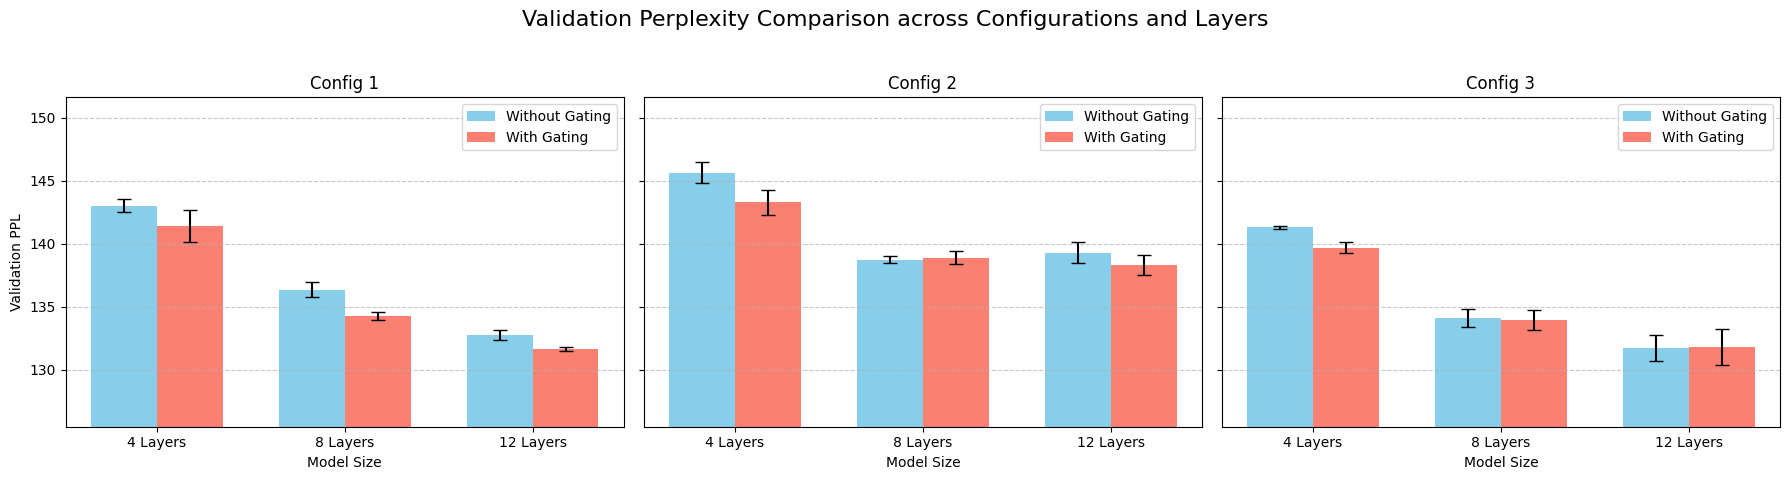

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data for plotting
layers = [4, 8, 12]
configs = [1, 2, 3]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('Validation Perplexity Comparison across Configurations and Layers', fontsize=16)

all_ppls = []

for i, config_num in enumerate(configs):
    ax = axes[i]

    no_gate_means = []
    no_gate_stds = []
    gate_means = []
    gate_stds = []

    for l in layers:
        # No Gate
        ng_key = f'no_gate_config{config_num}_L{l}'
        ng_res = multi_seed_results.get(ng_key, [])
        if ng_res:
            ng_val_losses = [float(r['val_loss_no_gate'][-1]) for r in ng_res]
            ng_val_ppls = [float(r.get('val_ppl_no_gate', [np.exp(vl)])[-1]) for r, vl in zip(ng_res, ng_val_losses)]
            no_gate_means.append(np.mean(ng_val_ppls))
            no_gate_stds.append(np.std(ng_val_ppls))
            all_ppls.extend(ng_val_ppls)
        else:
            no_gate_means.append(0)
            no_gate_stds.append(0)

        # Gate
        g_key = f'gate_config{config_num}_L{l}'
        g_res = multi_seed_results.get(g_key, [])
        if g_res:
            g_val_losses = [float(r['val_loss'][-1]) for r in g_res]
            g_val_ppls = [float(r.get('val_ppl', [np.exp(vl)])[-1]) for r, vl in zip(g_res, g_val_losses)]
            gate_means.append(np.mean(g_val_ppls))
            gate_stds.append(np.std(g_val_ppls))
            all_ppls.extend(g_val_ppls)
        else:
            gate_means.append(0)
            gate_stds.append(0)

    x = np.arange(len(layers))
    width = 0.35

    ax.bar(x - width/2, no_gate_means, width, yerr=no_gate_stds, label='Without Gating', capsize=5, color='skyblue')
    ax.bar(x + width/2, gate_means, width, yerr=gate_stds, label='With Gating', capsize=5, color='salmon')

    ax.set_title(f'Config {config_num}')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{l} Layers' for l in layers])
    ax.set_xlabel('Model Size')
    if i == 0:
        ax.set_ylabel('Validation PPL')
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust y-axis to zoom in on the differences
if all_ppls:
    min_val = min(all_ppls)
    max_val = max(all_ppls)
    plt.ylim(max(0, min_val - 5), max_val + 5)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [ ]:
import shutil
import os

local_pkl = '/content/multi_seed_results_checkpoint.pkl'
drive_pkl = '/content/drive/MyDrive/Data/multi_seed_results_checkpoint.pkl'

# Check if the local file exists before copying
if os.path.exists(local_pkl):
    # shutil.copy2 will copy the file and its metadata, overwriting the destination if it exists
    shutil.copy2(local_pkl, drive_pkl)
    print(f"Successfully copied {local_pkl} to {drive_pkl}")
else:
    print(f"Local file {local_pkl} does not exist.")


Successfully copied /content/multi_seed_results_checkpoint.pkl to /content/drive/MyDrive/Data/multi_seed_results_checkpoint.pkl
